In [1]:
# %% [markdown]
# # Step 1: Dependencies and NeuroKit2 Signal Cleaning

# %%
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LassoCV, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Check for NeuroKit2 availability
try:
    import neurokit2 as nk
    HAS_NEUROKIT = True
    print(f"NeuroKit2 {nk.__version__} loaded successfully.")
except ImportError:
    HAS_NEUROKIT = False
    print("NeuroKit2 not installed; falling back to Elgendi-equivalent Butterworth bandpass.")

FS = 50  # 50 Hz sampling rate

def clean_ppg_signal(raw_str, fs=FS, trim_start_sec=5.0, duration_sec=60.0, method="elgendi"):
    """
    Parses semicolon-separated values, trims 70s to the central 60s (dropping 5s start/end),
    and filters using NeuroKit2's PPG cleaning pipeline.
    """
    signal = np.fromstring(raw_str, sep=';', dtype=np.float64)
    
    # 70s -> 60s window (samples 250 to 3250 at 50 Hz)
    start_idx = int(trim_start_sec * fs)
    end_idx = start_idx + int(duration_sec * fs)
    trimmed_signal = signal[start_idx:end_idx]
    
    if HAS_NEUROKIT:
        # Elgendi (2012) 0.5-8 Hz bandpass tailored for fingertip optical PPG
        clean = nk.ppg_clean(trimmed_signal, sampling_rate=fs, method=method)
    else:
        # Exact Elgendi bandpass fallback (0.5 - 8 Hz 3rd-order Butterworth)
        nyq = 0.5 * fs
        b, a = butter(3, [0.5 / nyq, 8.0 / nyq], btype='band')
        clean = filtfilt(b, a, trimmed_signal)
        
    return clean

NeuroKit2 0.2.13 loaded successfully.


In [4]:
# %% [markdown]
# # Step 2: Comprehensive Feature Extraction

# %%
def extract_signal_features(clean_sig, fs=FS):
    feats = {}
    
    # Waveform statistical profiles
    feats['ppg_std'] = np.std(clean_sig)
    feats['ppg_skew'] = float(pd.Series(clean_sig).skew())
    feats['ppg_kurt'] = float(pd.Series(clean_sig).kurtosis())
    
    # First derivative (VPG) & second derivative (APG)
    vpg = np.gradient(clean_sig, 1.0 / fs)
    apg = np.gradient(vpg, 1.0 / fs)
    
    feats['vpg_max'] = np.max(vpg)
    feats['vpg_min'] = np.min(vpg)
    feats['vpg_std'] = np.std(vpg)
    feats['apg_max'] = np.max(apg)
    feats['apg_min'] = np.min(apg)
    feats['apg_ratio'] = abs(feats['apg_min']) / (abs(feats['apg_max']) + 1e-6)
    
    # Systolic peaks detection
    peaks, _ = find_peaks(clean_sig, distance=int(0.4 * fs), prominence=0.25 * np.std(clean_sig))
    
    if len(peaks) > 5:
        ibi = np.diff(peaks) / fs
        ibi_ms = ibi * 1000.0
        
        # HRV proxy features
        feats['mean_hr'] = 60.0 / np.mean(ibi)
        feats['hr_std'] = np.std(60.0 / ibi)
        feats['sdnn'] = np.std(ibi_ms)
        feats['rmssd'] = np.sqrt(np.mean(np.square(np.diff(ibi_ms))))
        feats['pnn50'] = np.sum(np.abs(np.diff(ibi_ms)) > 50) / len(ibi_ms)
        
        # Morphology (pulse amplitude & crest times)
        amps = [clean_sig[peaks[i]] - np.min(clean_sig[peaks[i]:peaks[i+1]]) for i in range(len(peaks) - 1)]
        feats['mean_pulse_amp'] = np.mean(amps)
        feats['std_pulse_amp'] = np.std(amps)
        crest_times = [(peaks[i] - (peaks[i-1] if i > 0 else 0)) / fs for i in range(len(peaks))]
        feats['crest_time'] = np.mean(crest_times)
    else:
        for k in ['mean_hr', 'hr_std', 'sdnn', 'rmssd', 'pnn50', 'mean_pulse_amp', 'std_pulse_amp', 'crest_time']:
            feats[k] = np.nan
            
    return feats

# Load dataset and extract feature matrix
csv_path = "data/real/glucosense_r_dataset_2026-09-17.csv"
df_raw = pd.read_csv(csv_path)

dataset_rows = []
for _, row in df_raw.iterrows():
    clean_sig = clean_ppg_signal(row['ppg_data'])
    feats = extract_signal_features(clean_sig)
    
    # Session metadata
    feats['participant_id'] = row['participant_id']
    feats['age'] = row['age']
    feats['is_female'] = 1 if str(row['gender']).strip().lower() == 'female' else 0
    feats['bmi'] = row['weight_kg'] / ((row['height_cm'] / 100.0) ** 2)
    feats['years_on_t2dm'] = row['years_on_t2dm']
    feats['is_postprandial'] = 0 if row['session_kind'] == 'fasting' else 1
    feats['bgl_mgdl'] = row['bgl_mgdl']
    
    dataset_rows.append(feats)

df_all = pd.DataFrame(dataset_rows).dropna()
print(f"Extraction complete: {df_all.shape[0]} sessions across {df_all['participant_id'].nunique()} participants.")

Extraction complete: 99 sessions across 87 participants.


In [5]:
# %% [markdown]
# # Step 3: Approach 1 — Univariate Filtering & Multicollinearity De-Duplication

# %%
def correlation_and_collinearity_filter(df, target_col='bgl_mgdl', exclude_cols=['participant_id'], 
                                        min_target_corr=0.08, max_feature_collinearity=0.85):
    """
    1. Filters features based on target correlation threshold |r| >= min_target_corr.
    2. Drops pairwise collinear features having |r| > max_feature_collinearity,
       retaining whichever has the higher correlation to the target.
    """
    X_cols = [c for c in df.columns if c not in [target_col] + exclude_cols]
    
    # 1. Target correlation check
    target_corrs = df[X_cols].apply(lambda s: s.corr(df[target_col])).abs()
    surviving_feats = target_corrs[target_corrs >= min_target_corr].sort_values(ascending=False).index.tolist()
    
    print(f"[Approach 1] Features passing |r| >= {min_target_corr}: {len(surviving_feats)}")
    
    # 2. Pairwise feature collinearity pruning
    corr_sub = df[surviving_feats].corr().abs()
    to_drop = set()
    
    for i in range(len(surviving_feats)):
        col_a = surviving_feats[i]
        if col_a in to_drop:
            continue
        for j in range(i + 1, len(surviving_feats)):
            col_b = surviving_feats[j]
            if col_b in to_drop:
                continue
            if corr_sub.loc[col_a, col_b] > max_feature_collinearity:
                # Retain the one with higher target correlation
                drop_target = col_b if target_corrs[col_a] >= target_corrs[col_b] else col_a
                to_drop.add(drop_target)
                
    selected_features = [f for f in surviving_feats if f not in to_drop]
    print(f"[Approach 1] Features retained after collinearity pruning (|r_xx| <= {max_feature_collinearity}): {selected_features}")
    return selected_features

selected_approach_1 = correlation_and_collinearity_filter(
    df_all, target_col='bgl_mgdl', min_target_corr=0.08, max_feature_collinearity=0.85
)

[Approach 1] Features passing |r| >= 0.08: 8
[Approach 1] Features retained after collinearity pruning (|r_xx| <= 0.85): ['is_postprandial', 'years_on_t2dm', 'pnn50', 'ppg_skew', 'rmssd', 'vpg_std']


In [6]:
# %% [markdown]
# # Step 4: Approach 2 — Regularized Embedded Selection (LassoCV)

# %%
X_raw = df_all.drop(columns=['bgl_mgdl', 'participant_id'])
y_raw = df_all['bgl_mgdl']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Group-aware or 5-fold cross-validated Lasso to identify sparse non-zero coefficients
lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_scaled, y_raw)

lasso_coefs = pd.Series(lasso.coef_, index=X_raw.columns)
selected_approach_2 = lasso_coefs[lasso_coefs.abs() > 1e-4].sort_values(key=abs, ascending=False).index.tolist()

print(f"[Approach 2] Optimal Alpha: {lasso.alpha_:.4f}")
print(f"[Approach 2] Non-zero features selected ({len(selected_approach_2)}):")
print(lasso_coefs[selected_approach_2])

[Approach 2] Optimal Alpha: 4.3461
[Approach 2] Non-zero features selected (3):
is_postprandial    18.460083
years_on_t2dm       6.970266
pnn50              -5.062073
dtype: float64


In [7]:
# %% [markdown]
# # Step 4: Approach 2 — Regularized Embedded Selection (LassoCV)

# %%
X_raw = df_all.drop(columns=['bgl_mgdl', 'participant_id'])
y_raw = df_all['bgl_mgdl']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Group-aware or 5-fold cross-validated Lasso to identify sparse non-zero coefficients
lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_scaled, y_raw)

lasso_coefs = pd.Series(lasso.coef_, index=X_raw.columns)
selected_approach_2 = lasso_coefs[lasso_coefs.abs() > 1e-4].sort_values(key=abs, ascending=False).index.tolist()

print(f"[Approach 2] Optimal Alpha: {lasso.alpha_:.4f}")
print(f"[Approach 2] Non-zero features selected ({len(selected_approach_2)}):")
print(lasso_coefs[selected_approach_2])

[Approach 2] Optimal Alpha: 4.3461
[Approach 2] Non-zero features selected (3):
is_postprandial    18.460083
years_on_t2dm       6.970266
pnn50              -5.062073
dtype: float64


[Approach 3] Optimal number of features identified by RFECV: 6
[Approach 3] Selected feature subset: ['ppg_std', 'vpg_min', 'vpg_std', 'age', 'years_on_t2dm', 'is_postprandial']


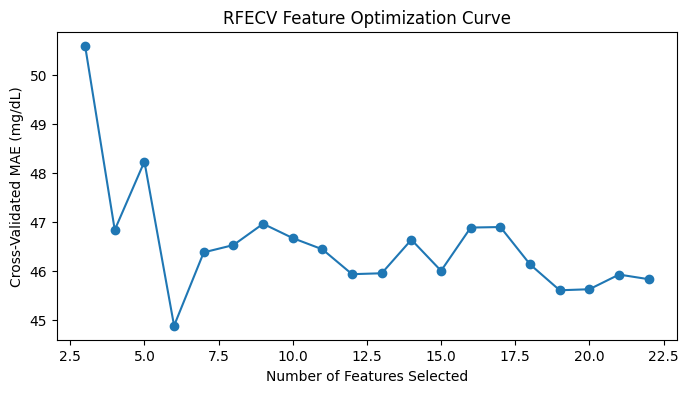

In [8]:
# %% [markdown]
# # Step 5: Approach 3 — Recursive Feature Elimination (RFECV)

# %%
gkf = GroupKFold(n_splits=5)
groups = df_all['participant_id']

# Use Random Forest Regressor as the estimator inside RFECV
rf_base = RandomForestRegressor(n_estimators=60, max_depth=4, random_state=42)

rfecv = RFECV(
    estimator=rf_base,
    step=1,
    cv=gkf.split(X_raw, y_raw, groups=groups),
    scoring='neg_mean_absolute_error',
    min_features_to_select=3,
    n_jobs=-1
)
rfecv.fit(X_raw, y_raw)

selected_approach_3 = X_raw.columns[rfecv.support_].tolist()

print(f"[Approach 3] Optimal number of features identified by RFECV: {rfecv.n_features_}")
print(f"[Approach 3] Selected feature subset: {selected_approach_3}")

# Plot RFECV performance trajectory
plt.figure(figsize=(8, 4))
plt.plot(range(3, len(rfecv.cv_results_['mean_test_score']) + 3), -rfecv.cv_results_['mean_test_score'], marker='o')
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validated MAE (mg/dL)")
plt.title("RFECV Feature Optimization Curve")
plt.show()

In [9]:
# %% [markdown]
# # Step 6: Side-by-Side Model Evaluation across Selection Methods

# %%
feature_sets = {
    "All Features (Baseline)": list(X_raw.columns),
    "Approach 1 (Pearson Filter + De-correlation)": selected_approach_1,
    "Approach 2 (Lasso Sparse Path)": selected_approach_2,
    "Approach 3 (RFECV Wrapper)": selected_approach_3
}

benchmark_results = []

for set_name, feature_list in feature_sets.items():
    X_subset = df_all[feature_list]
    
    # Evaluate with Random Forest under identical 5-fold GroupKFold splits
    model = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_split=4, random_state=42)
    scores = cross_validate(
        model, X_subset, y_raw, 
        groups=groups, cv=gkf, 
        scoring={'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}
    )
    
    benchmark_results.append({
        "Feature Selection Strategy": set_name,
        "Num Features": len(feature_list),
        "MAE (mg/dL)": -np.mean(scores['test_mae']),
        "RMSE (mg/dL)": -np.mean(scores['test_rmse']),
        "R² Score": np.mean(scores['test_r2'])
    })

results_df = pd.DataFrame(benchmark_results).set_index("Feature Selection Strategy")
print("\n=== Out-of-Fold Performance Comparison ===")
display(results_df.round(3))


=== Out-of-Fold Performance Comparison ===


,Num Features,MAE (mg/dL),RMSE (mg/dL),R² Score
Feature Selection Strategy,,,,
All Features (Baseline),22,47.097,63.301,-0.222
Approach 1 (Pearson Filter + De-correlation),6,46.541,63.577,-0.313
Approach 2 (Lasso Sparse Path),3,41.538,56.587,0.060
Approach 3 (RFECV Wrapper),6,43.800,58.338,-0.046


In [10]:
# %% [markdown]
# # Multi-Algorithm Benchmark for Non-Invasive BGL Estimation
# Evaluates CatBoost, XGBoost, LightGBM, SVR, ElasticNet, and Voting Regressors
# using GroupKFold cross-validation on participant_id.

# %%
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tree-based algorithms
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, ExtraTreesRegressor

# Kernel and linear baselines
from sklearn.svm import SVR
from sklearn.linear_model import ElasticNet

# Choose which feature subset to benchmark (e.g. selected_approach_1, selected_approach_2, selected_approach_3)
ACTIVE_FEATURES = selected_approach_3  # Change to any selection subset from previous cells

X = df_all[ACTIVE_FEATURES].copy()
y = df_all['bgl_mgdl'].copy()
groups = df_all['participant_id'].values

# Define the models configured with regularization to avoid overfitting small cohorts
def get_model_suite():
    return {
        "Ridge / ElasticNet": Pipeline([
            ('scaler', StandardScaler()),
            ('reg', ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=3000))
        ]),
        
        "Support Vector Regressor (SVR)": Pipeline([
            ('scaler', StandardScaler()),
            ('reg', SVR(kernel='rbf', C=15.0, epsilon=5.0, gamma='scale'))
        ]),
        
        "Random Forest": RandomForestRegressor(
            n_estimators=120, max_depth=5, min_samples_split=4, random_state=42
        ),
        
        "Extra Trees": ExtraTreesRegressor(
            n_estimators=120, max_depth=5, min_samples_split=4, random_state=42
        ),
        
        "XGBoost": xgb.XGBRegressor(
            n_estimators=80,
            max_depth=3,
            learning_rate=0.04,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=1.0,
            reg_lambda=2.0,
            random_state=42,
            verbosity=0
        ),
        
        "LightGBM": lgb.LGBMRegressor(
            n_estimators=80,
            max_depth=3,
            num_leaves=7,
            learning_rate=0.04,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.5,
            reg_lambda=1.5,
            random_state=42,
            verbose=-1
        ),
        
        "CatBoost": CatBoostRegressor(
            iterations=120,
            depth=4,
            learning_rate=0.04,
            l2_leaf_reg=4.0,
            random_seed=42,
            verbose=False
        )
    }

# %% [markdown]
# ### Run Leak-Free GroupKFold Cross-Validation

# %%
gkf = GroupKFold(n_splits=5)
models = get_model_suite()

# Also prepare an ensemble blending the strongest distinct model families
ensemble_regressor = VotingRegressor(
    estimators=[
        ('catboost', models['CatBoost']),
        ('xgboost', models['XGBoost']),
        ('svr', models['Support Vector Regressor (SVR)']),
        ('rf', models['Random Forest'])
    ]
)
models["Voting Ensemble (Blend)"] = ensemble_regressor

benchmark_records = []
oof_predictions = {name: np.zeros(len(y)) for name in models.keys()}

for name, model in models.items():
    fold_mae, fold_rmse, fold_r2 = [], [], []
    
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # Fit model on training fold
        model.fit(X_train, y_train)
        
        # Predict on validation fold
        val_pred = model.predict(X_val)
        oof_predictions[name][val_idx] = val_pred
        
        # Metrics per fold
        fold_mae.append(mean_absolute_error(y_val, val_pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_val, val_pred)))
        fold_r2.append(r2_score(y_val, val_pred))
        
    benchmark_records.append({
        "Model": name,
        "Mean MAE (mg/dL)": np.mean(fold_mae),
        "Std MAE": np.std(fold_mae),
        "Mean RMSE (mg/dL)": np.mean(fold_rmse),
        "Mean R²": np.mean(fold_r2)
    })

results_df = pd.DataFrame(benchmark_records).sort_values("Mean MAE (mg/dL)").reset_index(drop=True)

print(f"=== Multi-Model Benchmark on {len(ACTIVE_FEATURES)} Selected Features ===")
display(results_df.round(3))

=== Multi-Model Benchmark on 6 Selected Features ===


,Model,Mean MAE (mg/dL),Std MAE,Mean RMSE (mg/dL),Mean R²
0,LightGBM,42.113,3.946,56.712,0.040
1,Support Vector Regressor (SVR),42.118,8.442,58.031,0.020
2,Ridge / ElasticNet,42.196,5.413,56.826,0.044
3,Voting Ensemble (Blend),42.206,5.912,55.910,0.071
4,CatBoost,42.307,5.376,55.693,0.072
5,XGBoost,42.497,5.689,56.123,0.055
6,Extra Trees,43.818,2.874,58.957,-0.063
7,Random Forest,43.947,4.892,58.511,-0.055
